In [536]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# **Step - 1: Understanding Data :**

In [538]:
fraud_train = pd.read_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/raw/fraudTrain.csv')

In [539]:
fraud_test = pd.read_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/raw/fraudTest.csv')
fraud_test['is_fraud'].unique()

array([0, 1], dtype=int64)

In [540]:
fraud_test, validation = train_test_split(fraud_test, test_size=0.5, random_state=42)
fraud_test.to_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/processed/fraudTest.csv', index=False)
validation.to_csv('C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/processed/validation.csv', index=False)
validation_df = pd.read_csv("C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/data/processed/validation.csv")

In [541]:
df = fraud_train.copy()

In [542]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [543]:
df.drop(df.columns[:1], axis=1, inplace=True)

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [545]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [546]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
print(df.dtypes['trans_date_trans_time'])

datetime64[ns]


In [547]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [548]:
df.nunique()

trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
dtype: int64

# **Step - 2: Data pre-processing**

In [550]:
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
#deriving 'day of the week'
df['trans_day_of_week'] = df['trans_date_trans_time'].dt.day_name()
#deriving 'year_month'
df['trans_year_month'] = df['trans_date_trans_time'].dt.to_period('M')

df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,Tuesday,2019-01
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,Tuesday,2019-01
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,Tuesday,2019-01
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,Tuesday,2019-01
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,Tuesday,2019-01


In [551]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = np.round((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25)

In [552]:
df['age']

0          31.0
1          41.0
2          57.0
3          52.0
4          33.0
           ... 
1296670    59.0
1296671    41.0
1296672    53.0
1296673    40.0
1296674    25.0
Name: age, Length: 1296675, dtype: float64

In [553]:
df.drop(['trans_date_trans_time','first', 'last', 'dob'] , axis=1, inplace=True)
df.head()

,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,...,job,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_year_month,age
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,...,"Psychologist, counselling",0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,Tuesday,2019-01,31.0
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,...,Special educational needs teacher,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,Tuesday,2019-01,41.0
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,...,Nature conservation officer,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,Tuesday,2019-01,57.0
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,...,Patent attorney,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,Tuesday,2019-01,52.0
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,...,Dance movement psychotherapist,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,Tuesday,2019-01,33.0


In [554]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column             Non-Null Count    Dtype    
---  ------             --------------    -----    
 0   cc_num             1296675 non-null  int64    
 1   merchant           1296675 non-null  object   
 2   category           1296675 non-null  object   
 3   amt                1296675 non-null  float64  
 4   gender             1296675 non-null  object   
 5   street             1296675 non-null  object   
 6   city               1296675 non-null  object   
 7   state              1296675 non-null  object   
 8   zip                1296675 non-null  int64    
 9   lat                1296675 non-null  float64  
 10  long               1296675 non-null  float64  
 11  city_pop           1296675 non-null  int64    
 12  job                1296675 non-null  object   
 13  trans_num          1296675 non-null  object   
 14  unix_time          1296675 non-null  int64    
 15

In [555]:
df_org = df.copy()

# **Step - 3: Exploratory Data Analysis [EDA]**

In [557]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,1.280486e+01,4.599746e+01
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,6.817824e+00,1.739607e+01
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,0.000000e+00,1.400000e+01
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,7.000000e+00,3.300000e+01
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,1.400000e+01,4.400000e+01
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,1.900000e+01,5.700000e+01
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,2.300000e+01,9.600000e+01


In [558]:
100*df.is_fraud.value_counts(normalize=True)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

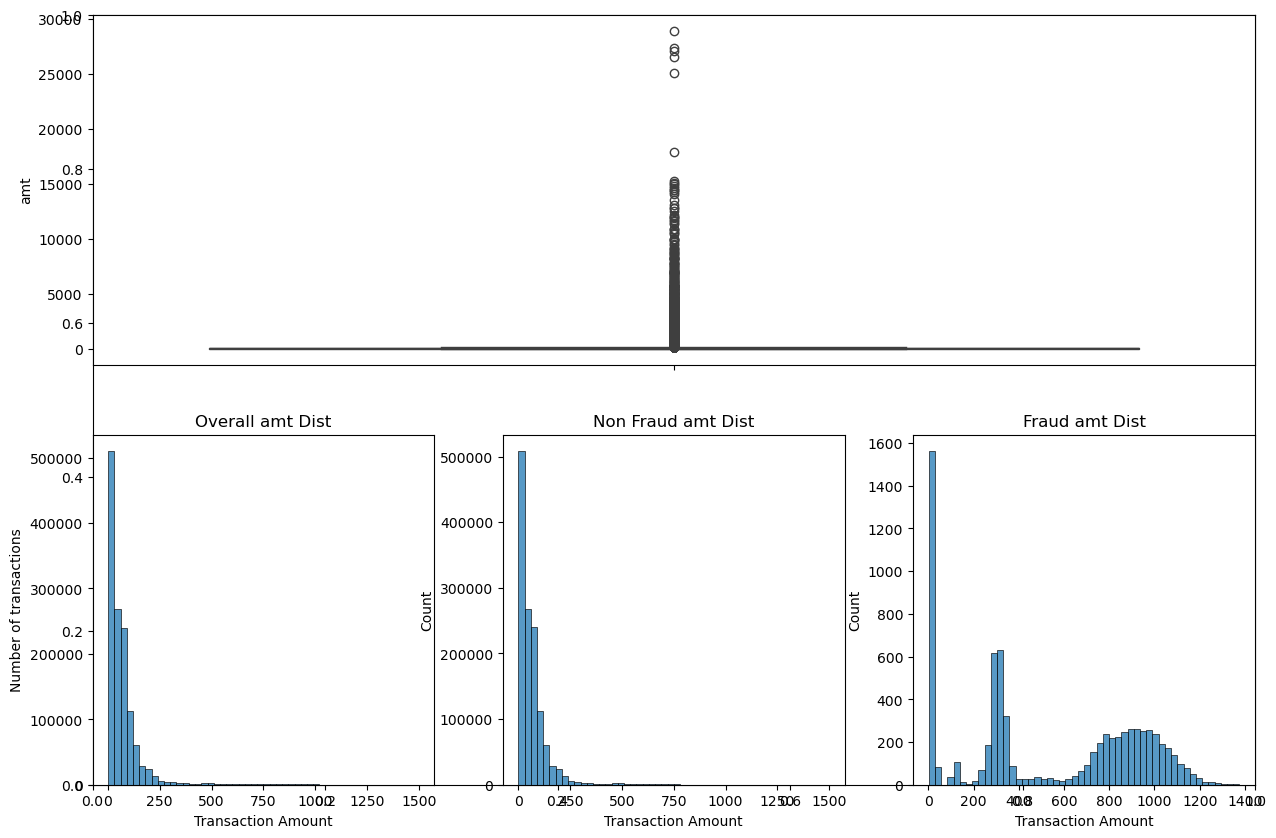

In [559]:
fig = plt.subplots(figsize=(15,10))
plots = []
plots.append(sns.boxplot(df.amt, ax=plt.subplot(211)))
plots.append(sns.histplot(df[df.amt <= 1500].amt, bins=50, ax=plt.subplot(234)))
plots.append(sns.histplot(df[(df.is_fraud==0) & (df.amt<=1500)].amt, bins=50, ax=plt.subplot(235)))
plots.append(sns.histplot(df[(df.is_fraud==1) & (df.amt<=1500)].amt, bins=50, ax=plt.subplot(236)))
plots[1].set_title('Overall amt Dist')
plots[2].set_title('Non Fraud amt Dist')
plots[3].set_title('Fraud amt Dist')
plots[1].set_xlabel('Transaction Amount')
plots[2].set_xlabel('Transaction Amount')
plots[3].set_xlabel('Transaction Amount')
plots[1].set_ylabel('Number of transactions')

plt.show()

##### **Observation ('amt' Feature):**
- The 'amt' feature shows significant outliers, indicating high variance.
- The overall and non-fraud amount distributions are similar, but the fraud amount mean is higher.
- Skewness in the data is evident.

##### **Inference:**
- Despite a higher mean for fraud amounts, they are evenly distributed and often involve smaller values compared to non-fraud transactions.
- Fraud transactions typically occur around 200, **sometimes ranging up to** 400.
- Closer monitoring of small-amount transactions can help detect and prevent credit card fraud.

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\463309281.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\463309281.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)


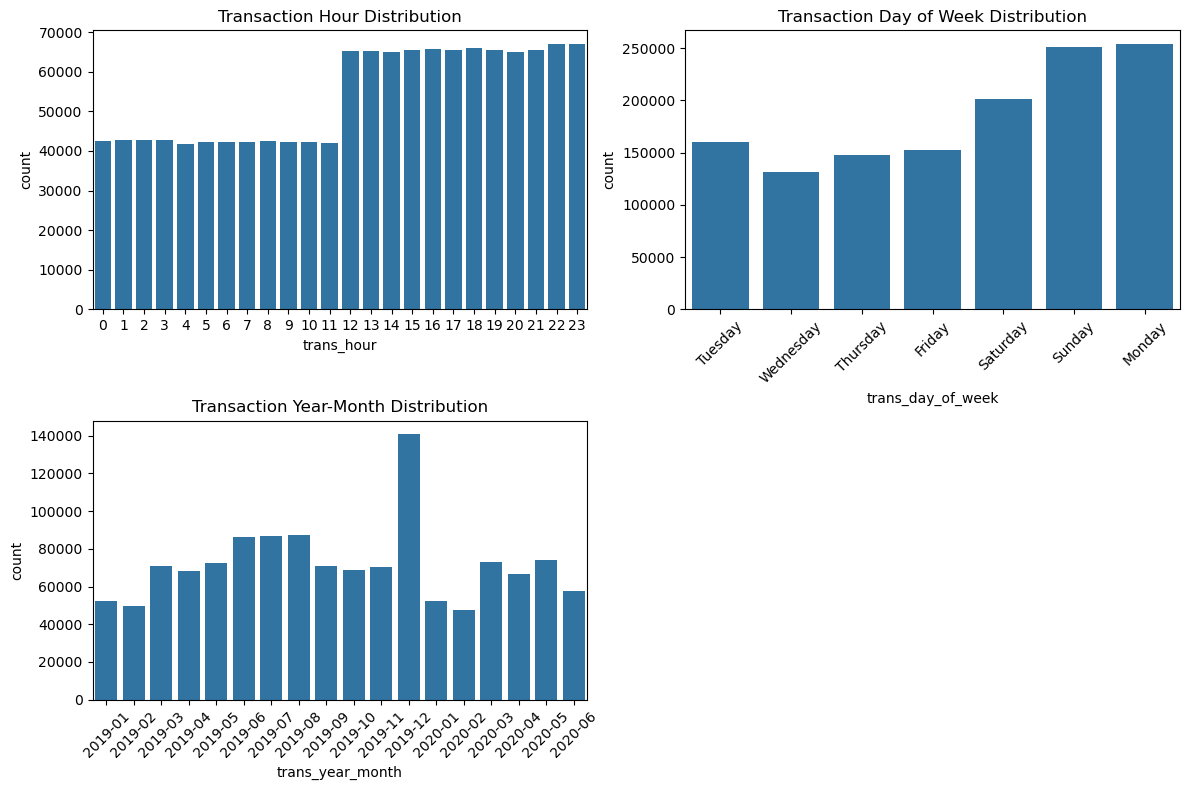

In [561]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 
sns.countplot(x=df['trans_hour'], ax=axes[0, 0])
axes[0, 0].set_title("Transaction Hour Distribution")

sns.countplot(x=df['trans_day_of_week'], ax=axes[0, 1])
axes[0, 1].set_title("Transaction Day of Week Distribution")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)  

sns.countplot(x=df['trans_year_month'], ax=axes[1, 0])
axes[1, 0].set_title("Transaction Year-Month Distribution")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

fig.delaxes(axes[1, 1])

plt.tight_layout()  
plt.show()


In [562]:
df_timeline01 = df.groupby(df['trans_year_month'])[['trans_num','cc_num']].nunique().reset_index()
df_timeline01.columns = ['year_month','num_of_transactions','customers']
df_timeline01

,year_month,num_of_transactions,customers
0,2019-01,52525,913
1,2019-02,49866,918
2,2019-03,70939,916
3,2019-04,68078,913
4,2019-05,72532,910
5,2019-06,86064,908
6,2019-07,86596,910
7,2019-08,87359,911
8,2019-09,70652,913
9,2019-10,68758,912


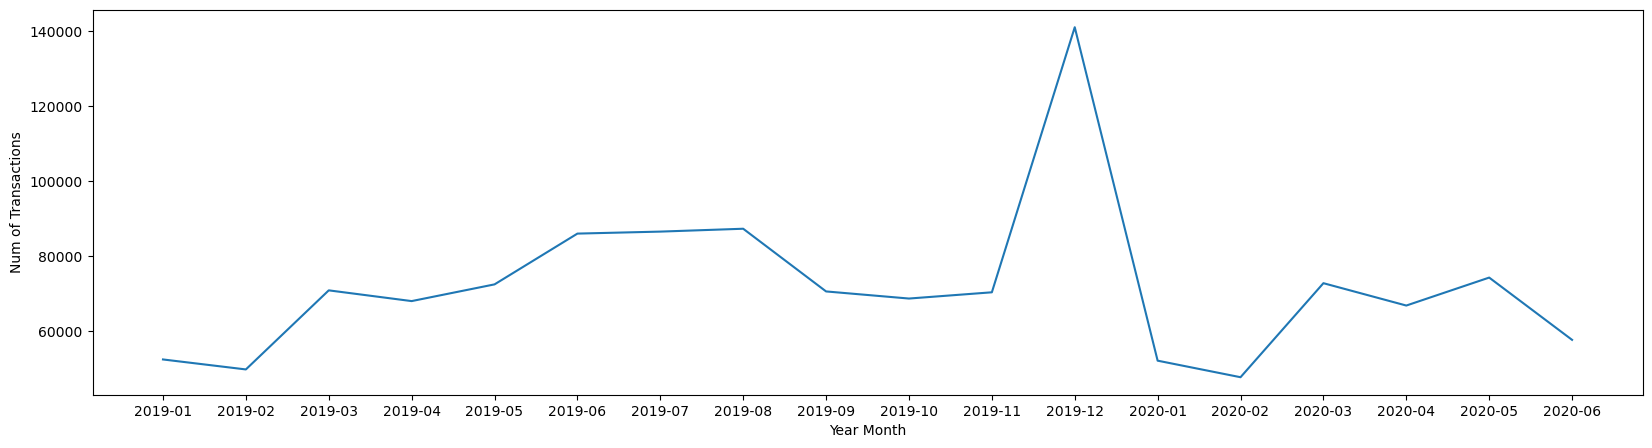

In [563]:
x = np.arange(0,len(df_timeline01),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,df_timeline01['num_of_transactions'])
ax.set_xticks(x)
ax.set_xticklabels(df_timeline01['year_month'])

ax.set_xlabel('Year Month')
ax.set_ylabel('Num of Transactions')
plt.show()

In [564]:
df_fraud_transactions = df[df['is_fraud']==1]

df_timeline02 = df_fraud_transactions.groupby(df_fraud_transactions['trans_year_month'])[['trans_num','cc_num']].nunique().reset_index()
df_timeline02.columns = ['year_month','num_of_fraud_transactions','fraud_customers']
df_timeline02

,year_month,num_of_fraud_transactions,fraud_customers
0,2019-01,506,50
1,2019-02,517,53
2,2019-03,494,49
3,2019-04,376,41
4,2019-05,408,42
5,2019-06,354,35
6,2019-07,331,36
7,2019-08,382,39
8,2019-09,418,44
9,2019-10,454,50


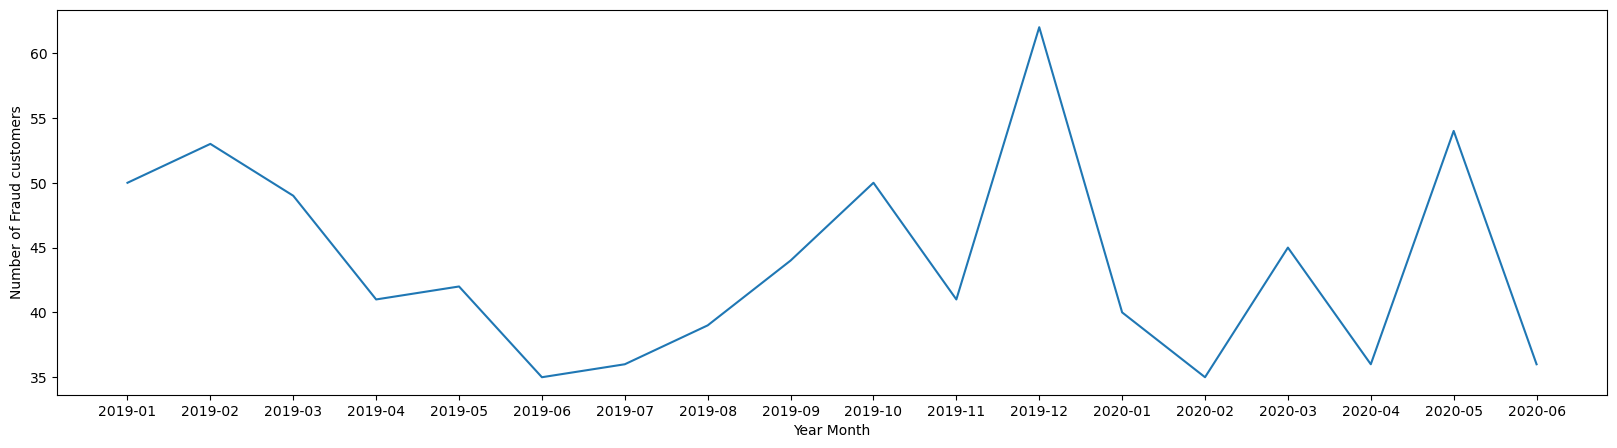

In [565]:
x = np.arange(0,len(df_timeline02),1)

fig, ax = plt.subplots(1,1,figsize=(20,5))
ax.plot(x,df_timeline02['fraud_customers'])
ax.set_xticks(x)
ax.set_xticklabels(df_timeline02['year_month'])

ax.set_xlabel('Year Month')
ax.set_ylabel('Number of Fraud customers')
plt.show()

#### **Observation (Time Data):**
- Most transactions occur in the afternoon (after 12 PM) and on Sundays and Mondays.
- Peak transaction months include January, February, October, December 2019, and May 2020.
- Fraud cases and transactions spike in December, coinciding with the holiday season.


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2595475865.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.s

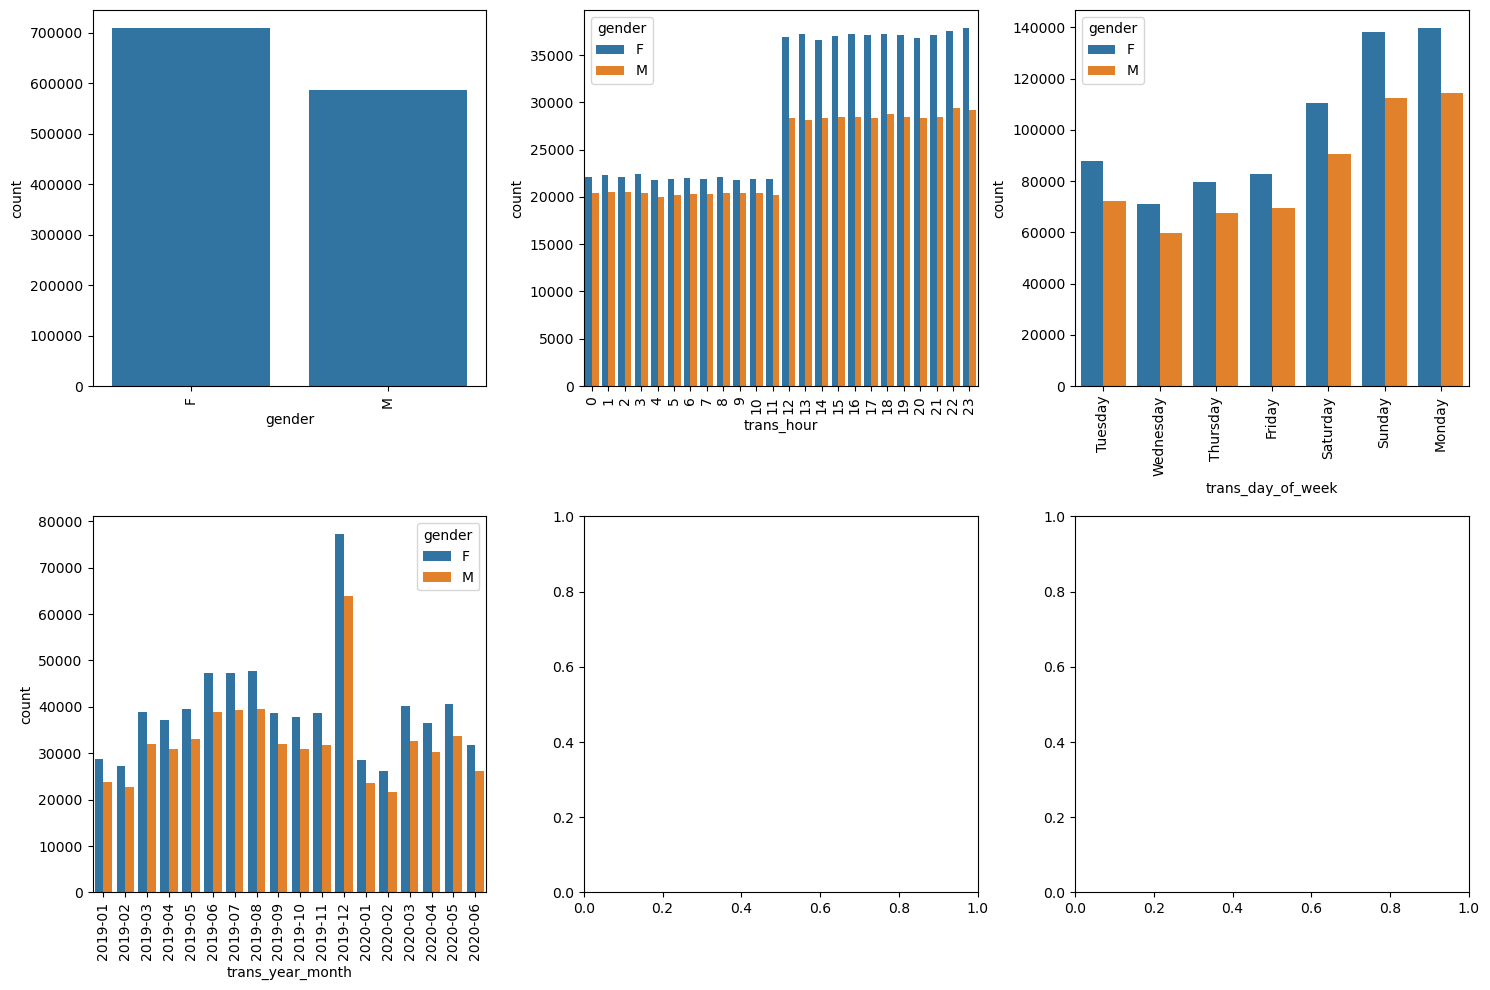

In [567]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # Create all subplots in a grid
axes = axes.flatten()  # Flatten for easy access

# Create a list to store plots
plots = []

# Gender demographic with respect to transactions
plots.append(sns.countplot(data=df, x='gender', ax=axes[0]))

# Transactions over time with respect to gender
plots.append(sns.countplot(data=df, x='trans_hour', hue='gender', ax=axes[1]))
plots.append(sns.countplot(data=df, x='trans_day_of_week', hue='gender', ax=axes[2]))
plots.append(sns.countplot(data=df, x='trans_year_month', hue='gender', ax=axes[3]))

# Rotate x-axis labels for all plots
for plot in plots:
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


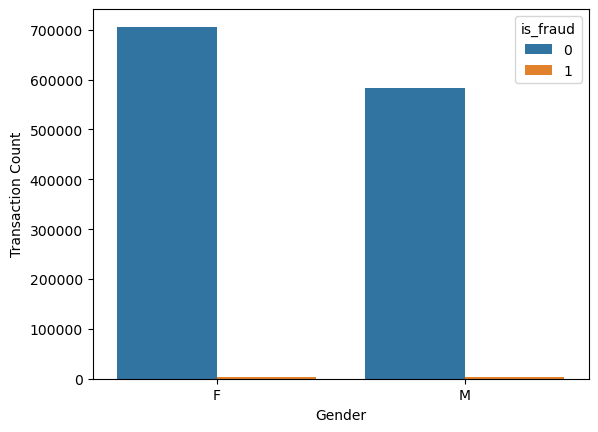

In [568]:
#creating the 'gender' distributed dataframe
df_gender = df[['gender','trans_num']].groupby(['gender']).count().reset_index()
df_gender.columns = ['Gender', 'gender_count']

#creating gender-fraud distribution
df_fraud_gender = df[['gender','trans_num', 'is_fraud']].groupby(['gender','is_fraud']).count().reset_index()
df_fraud_gender.columns = ['Gender', 'is_fraud', 'Transaction Count']

df_fraud_gender = df_fraud_gender.merge(df_gender[['Gender', 'gender_count']], how='inner', on='Gender')

df_fraud_gender['Transaction percentage'] = (df_fraud_gender['Transaction Count']/df_fraud_gender['gender_count'])*100

df_fraud_gender
sns.barplot(data=df_fraud_gender, y='Transaction Count', x='Gender', hue='is_fraud')
plt.show()

Gender-wise Fraud Distribution:


,Gender,is_fraud,Transaction_Count,Total_Transactions,Percentage
0,F,0,706128,709863,99.47
1,F,1,3735,709863,0.53
2,M,0,583041,586812,99.36
3,M,1,3771,586812,0.64


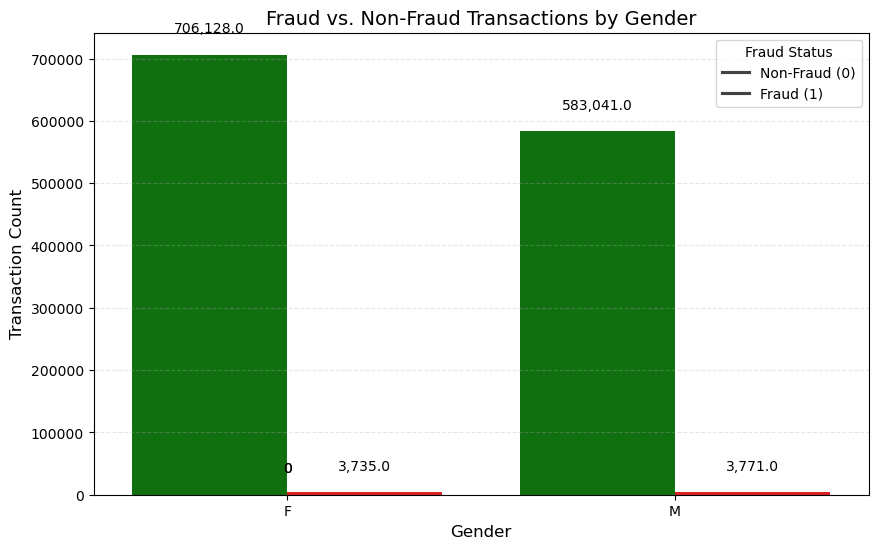

In [569]:
# 1. Gender Distribution (Total Transactions)
df_gender = df[['gender', 'trans_num']].groupby('gender').count().reset_index()
df_gender.columns = ['Gender', 'Total_Transactions']

# 2. Gender-Fraud Distribution (Fraud vs. Non-Fraud)
df_fraud_gender = (
    df[['gender', 'is_fraud', 'trans_num']]
    .groupby(['gender', 'is_fraud'])
    .count()
    .reset_index()
)
df_fraud_gender.columns = ['Gender', 'is_fraud', 'Transaction_Count']

# Merge to calculate percentages
df_fraud_gender = df_fraud_gender.merge(
    df_gender, on='Gender', how='left'
)
df_fraud_gender['Percentage'] = (
    df_fraud_gender['Transaction_Count'] / df_fraud_gender['Total_Transactions'] * 100
).round(2)

# Display the table
print("Gender-wise Fraud Distribution:")
display(df_fraud_gender)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_fraud_gender,
    x='Gender',
    y='Transaction_Count',
    hue='is_fraud',
    palette={0: 'green', 1: 'red'}  # Non-fraud: green, Fraud: red
)

# Customize plot
plt.title('Fraud vs. Non-Fraud Transactions by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.legend(title='Fraud Status', labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add percentage labels on bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(
        p.get_x() + p.get_width() / 2,
        height + 0.05 * df_fraud_gender['Transaction_Count'].max(),
        f'{height:,}',
        ha='center'
    )

plt.show()

##### **Observation:**
- Women contribute the most to transaction frequencies.
- Fraud involvement is 0.52% for women and 0.64% for men relative to their transaction volumes.

In [571]:
#let us first bin the age feature
# for i in range(len(df.age)):
#   if df.age[i] <= 30:
#     df.age[i] = '< 30'
#   elif df.age[i] > 30 and df.age[i] <= 45:
#     df.age[i] = '30-45'
#   elif df.age[i] > 45 and df.age[i] <= 60:
#     df.age[i] = '46-60'
#   elif df.age[i] > 60 and df.age[i] <= 75:
#     df.age[i] = '61-75'
#   else:
#     df.age[i] = '> 75'

# df.age.head()

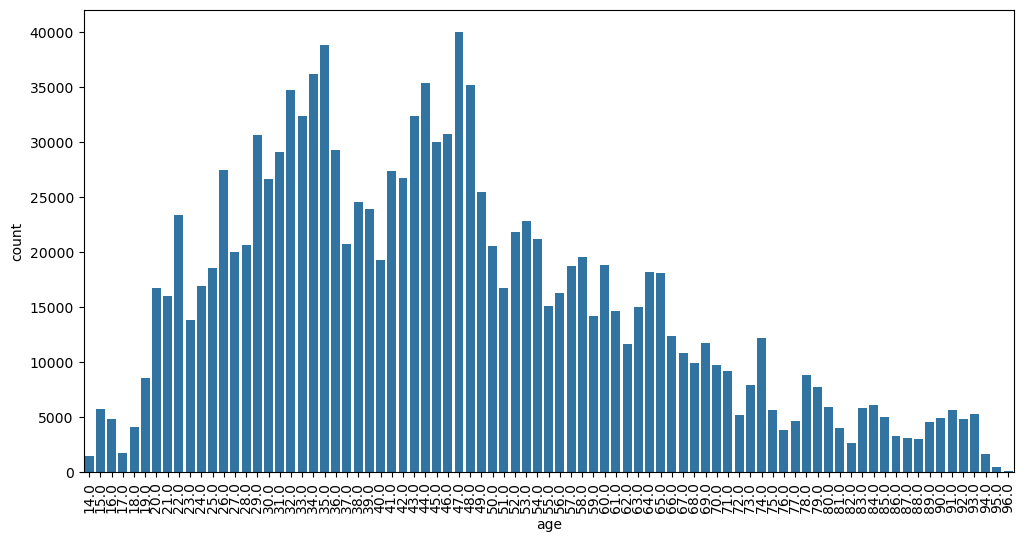

In [572]:
plt.figure(figsize=(12,6))
plot = sns.countplot(data=df, x='age') 
plt.xticks(rotation=90) 
plt.show()

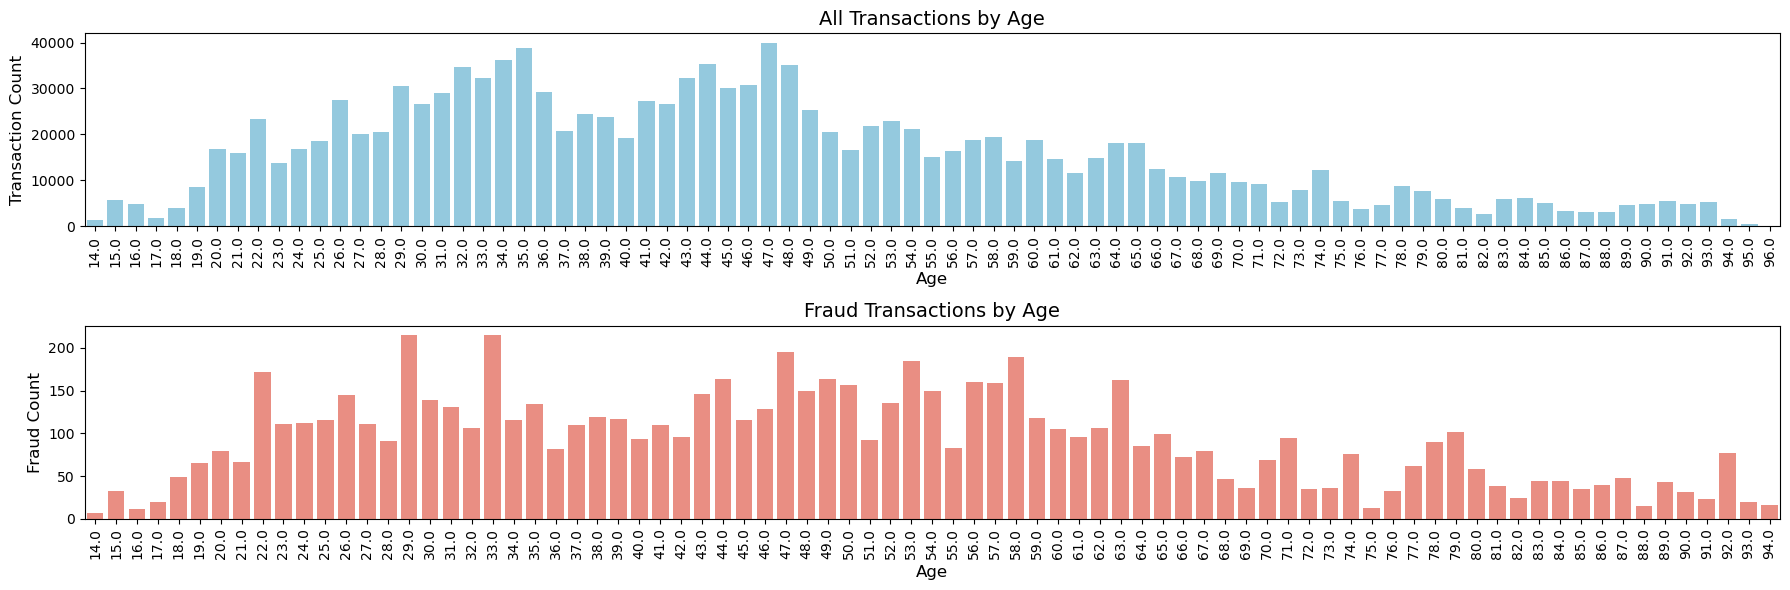

In [573]:
plt.figure(figsize=(18, 6))
plt.subplot(2, 1, 1)  # 1 row, 2 cols, position 1
ax1 = sns.countplot(data=df, x='age', color='skyblue')
plt.title('All Transactions by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=90)
plt.subplot(2, 1, 2)  # 1 row, 2 cols, position 2
ax2 = sns.countplot(data=df[df['is_fraud'] == 1], x='age', color='salmon')
plt.title('Fraud Transactions by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fraud Count', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()  # Prevent overlapping
plt.show()

###### **Observation (Age Groups):**
- The 30-45 age group accounts for the highest number of transactions, followed by the 46-60 age group.
- The >75 age group, while making fewer transactions, has the highest fraud rate (~1% of their transactions are fraudulent).


In [575]:
df.state.nunique()

51

since there are a lot of categories in the 'state' variable of the data, we will now only look at the top 20 states wherein the transaction frequencies are the highest.

In [577]:
high_trans_states = df.state.value_counts().head(20).index.tolist()
print(high_trans_states)

['TX', 'NY', 'PA', 'CA', 'OH', 'MI', 'IL', 'FL', 'AL', 'MO', 'MN', 'AR', 'NC', 'WI', 'VA', 'SC', 'KY', 'IN', 'IA', 'OK']


In [578]:
100*df[df.state.isin(high_trans_states)].state.value_counts(normalize=True)

state
TX    10.991718
NY     9.673884
PA     9.250555
CA     6.529504
OH     5.384871
MI     5.347103
IL     5.010896
FL     4.943585
AL     4.748720
MO     4.449122
MN     3.674178
AR     3.606172
NC     3.506422
WI     3.402386
VA     3.388715
SC     3.381764
KY     3.298929
IN     3.195240
IA     3.126307
OK     3.089929
Name: proportion, dtype: float64

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2094744530.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


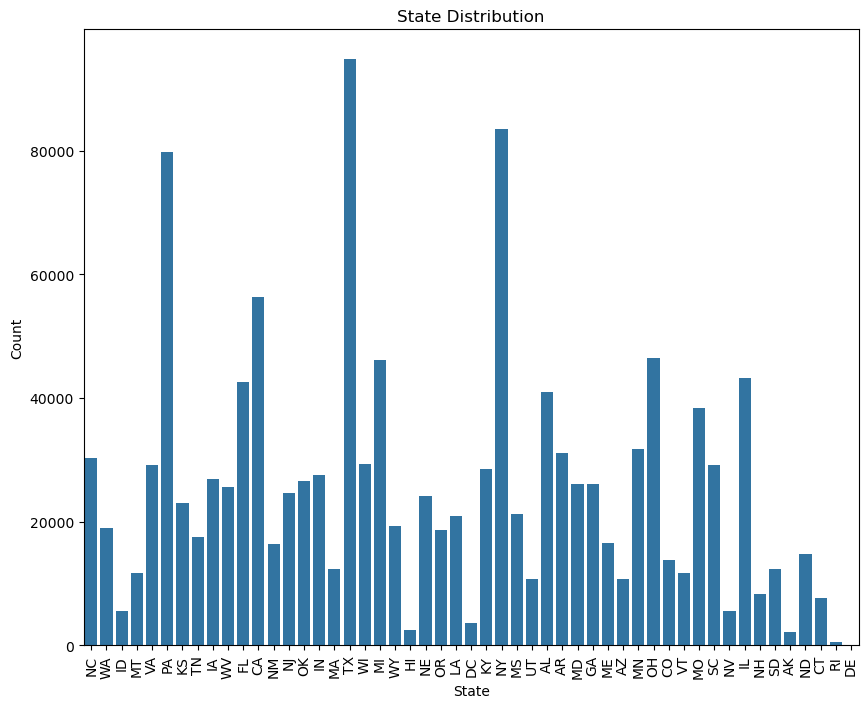

In [579]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x=df['state'], ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.xlabel("State")
plt.ylabel("Count")
plt.title("State Distribution")
plt.show()

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\3319515063.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


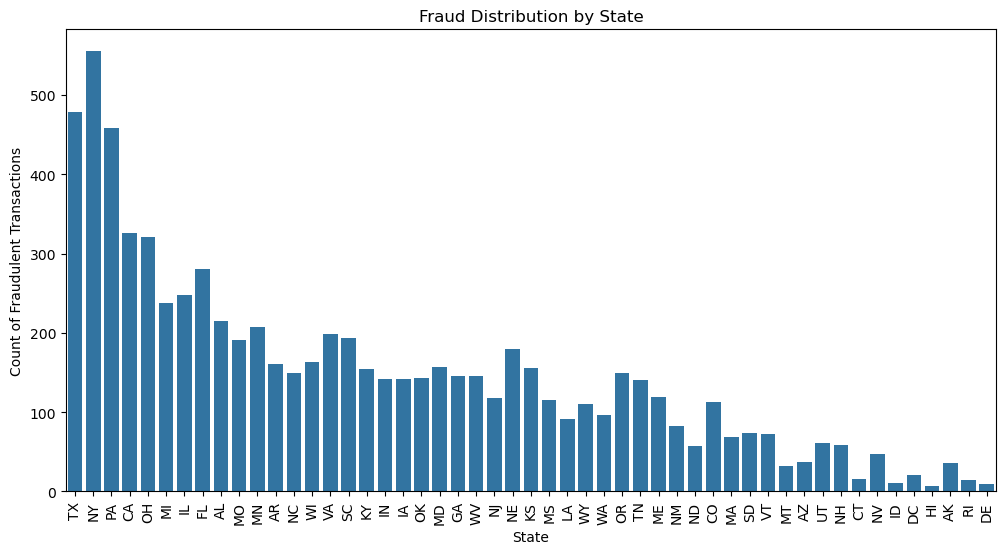

In [580]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(x=df[df['is_fraud'] == 1]['state'], ax=ax, order=df['state'].value_counts().index)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.xlabel("State")
plt.ylabel("Count of Fraudulent Transactions")
plt.title("Fraud Distribution by State")
plt.show()


In [581]:
#constructing the state-transaction count distribution
df_state = df[['state','trans_num']].groupby(['state']).count().reset_index()
df_state.columns = ['state', 'state_count']

#creating the state-fraud distribution
df_fraud_state = df[['state', 'trans_num', 'is_fraud']].groupby(['state','is_fraud']).count().reset_index()
df_fraud_state.columns = ['state', 'is_fraud', 'Transaction count']

df_fraud_state = df_fraud_state.merge(df_state[['state', 'state_count']], how='inner', on='state')

df_fraud_state['Transaction percentage'] = (df_fraud_state['Transaction count']/df_fraud_state['state_count'])*100

#viewing the top 20 states with high fraudulent transactions
df_fraud_state[df_fraud_state['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,state,is_fraud,Transaction count,state_count,Transaction percentage
16,DE,1,9,9,100.000000
78,RI,1,15,550,2.727273
1,AK,1,36,2120,1.698113
66,NV,1,47,5607,0.838238
11,CO,1,113,13880,0.814121
74,OR,1,149,18597,0.801204
84,TN,1,140,17554,0.797539
58,NE,1,180,24168,0.744786
42,ME,1,119,16505,0.720994
60,NH,1,59,8278,0.712733


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\1843818241.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


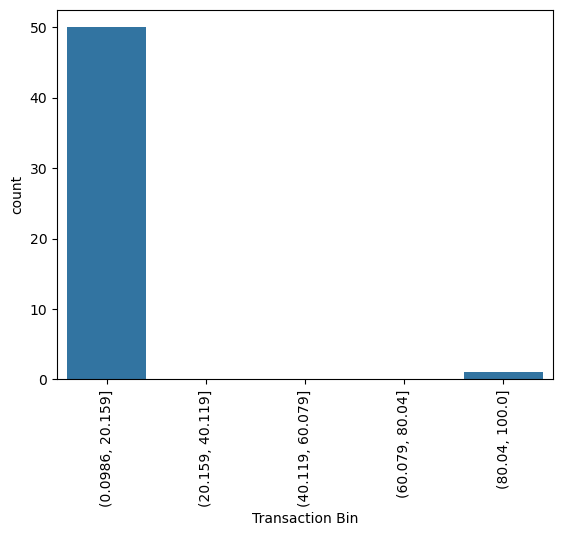

In [582]:
binned_data = pd.cut(df_fraud_state[df_fraud_state.is_fraud == 1]['Transaction percentage'], bins=5)

binned_df = pd.DataFrame({'Transaction Bin': binned_data})

plot = sns.countplot(data=binned_df, x='Transaction Bin')
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)

plt.show()

In [583]:
#states with more than 75% fraudulent transactions
print('state with more than 75% fraudulent transactions:\n')
print(df_fraud_state.loc[(df_fraud_state.is_fraud == 1) & (df_fraud_state['Transaction percentage'] >= 75)].state)

state with more than 75% fraudulent transactions:

16    DE
Name: state, dtype: object


#### **Observation (State Feature):**
- States like 'PA', 'TX', and 'NY' have the highest transaction volumes, followed by 'FL', 'CA', 'MI', 'AL', 'OH', and 'IL'.
- These states, with high transaction activity, are more prone to fraud through methods like ATM and POS tampering.
- All top 20 states with high transaction volumes have a fraud rate of ~0.5%, with 'DE' being the most fraudulent state.

In [585]:
print('number of cities: ',df.city.nunique())
print('number of zip codes: ',df.zip.nunique())

number of cities:  894
number of zip codes:  970


- Plotting a feature with a high number of unique values is challenging.
- Cities or zip codes with high transaction frequencies are more likely to experience fraud.
- To simplify visualization, we will focus on the top 20 cities and top 20 zip codes with the highest transaction frequencies.

In [587]:
high_trans_cities = df.city.value_counts().head(20).index.tolist()
high_trans_zips = df.zip.value_counts().head(20).index.tolist()
print('high frequencies cities: ', high_trans_cities)
print('high frequencies zip codes: ', high_trans_zips)

high frequencies cities:  ['Birmingham', 'San Antonio', 'Utica', 'Phoenix', 'Meridian', 'Thomas', 'Conway', 'Cleveland', 'Warren', 'Houston', 'Burbank', 'Naples', 'Arcadia', 'Indianapolis', 'Brandon', 'Fulton', 'Lahoma', 'Allentown', 'Lakeland', 'Dallas']
high frequencies zip codes:  [73754, 34112, 48088, 82514, 49628, 15484, 85173, 29819, 38761, 5461, 44233, 4287, 72042, 16858, 28405, 26292, 12419, 80120, 6024, 98238]


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\4065395168.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\4065395168.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


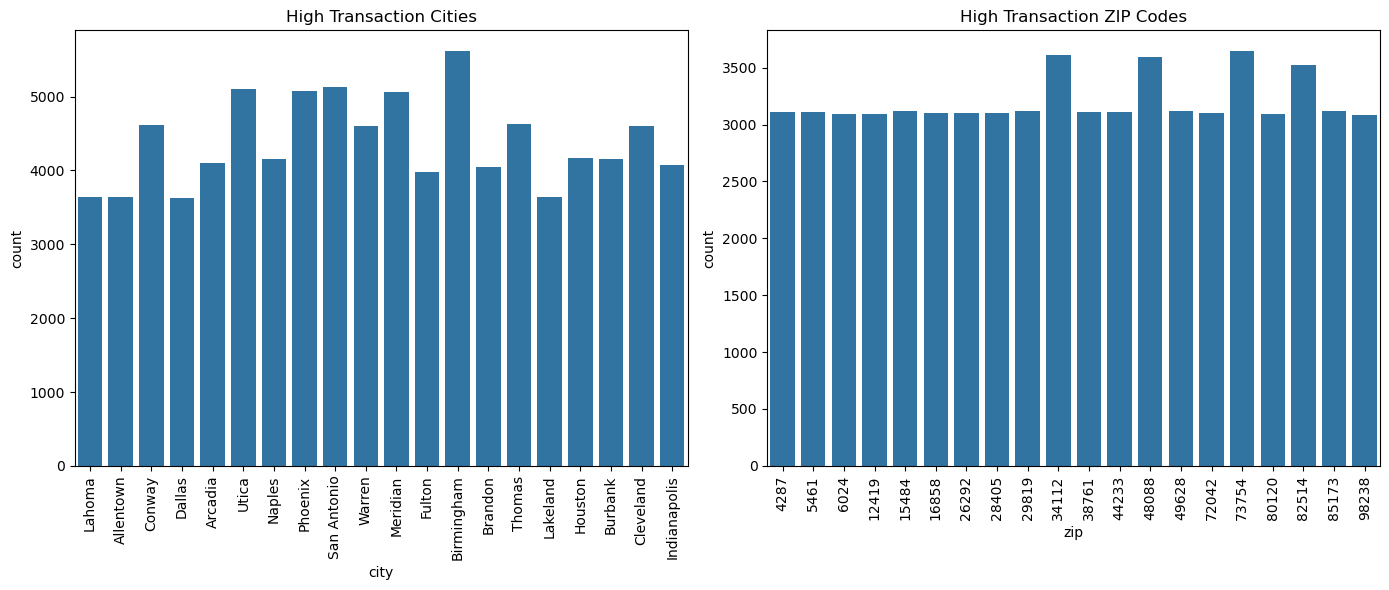

In [588]:
filtered_cities = df[df.city.isin(high_trans_cities)]
filtered_zips = df[df.zip.isin(high_trans_zips)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x="city", data=filtered_cities, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_title("High Transaction Cities")

sns.countplot(x="zip", data=filtered_zips, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)
axes[1].set_title("High Transaction ZIP Codes")

plt.tight_layout()
plt.show()

In [589]:
#constructing the city-transaction count distribution
df_city = df[['city','trans_num']].groupby(['city']).count().reset_index()
df_city.columns = ['city', 'city_count']

#creating the city-fraud distribution
df_fraud_city = df[['city', 'trans_num', 'is_fraud']].groupby(['city','is_fraud']).count().reset_index()
df_fraud_city.columns = ['city', 'is_fraud', 'Transaction count']

df_fraud_city = df_fraud_city.merge(df_city[['city', 'city_count']], how='inner', on='city')

df_fraud_city['Transaction percentage'] = (df_fraud_city['Transaction count']/df_fraud_city['city_count'])*100

#viewing the top 20 cities with high fraudulent transaction volumes
df_fraud_city[df_fraud_city['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,city,is_fraud,Transaction count,city_count,Transaction percentage
401,East China,1,9,9,100.0
1441,Walkertown,1,11,11,100.0
476,Freeport,1,9,9,100.0
483,Gaines,1,8,8,100.0
511,Granbury,1,12,12,100.0
1060,Orange Park,1,10,10,100.0
531,Greenport,1,10,10,100.0
101,Beacon,1,11,11,100.0
1444,Wappapello,1,8,8,100.0
989,Nicholson,1,9,9,100.0


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\1566233035.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\1566233035.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


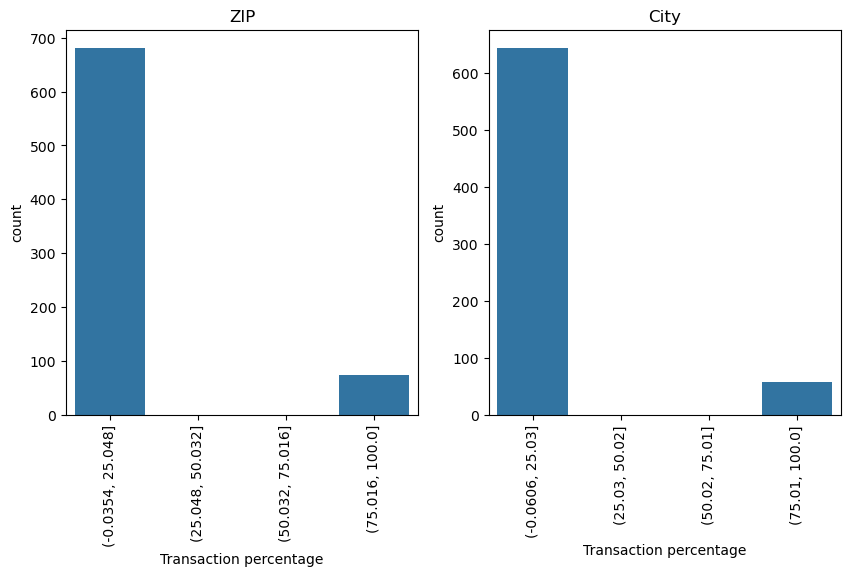

In [590]:
fraud_zip_filtered = df_fraud_zip.loc[df_fraud_zip['is_fraud'] == 1, 'Transaction percentage']
fraud_city_filtered = df_fraud_city.loc[df_fraud_city['is_fraud'] == 1, 'Transaction percentage']
if fraud_zip_filtered.empty or fraud_city_filtered.empty:
    print("Warning: No fraudulent transactions found in one of the datasets!")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.countplot(x=pd.cut(fraud_zip_filtered, bins=4), ax=axes[0])
    sns.countplot(x=pd.cut(fraud_city_filtered, bins=4), ax=axes[1])
    axes[0].set_title('ZIP')
    axes[1].set_title('City')
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

In [591]:
print('Cities with more than 75% fraudulent transactions:\n')
print(df_fraud_city.loc[(df_fraud_city.is_fraud == 1) & (df_fraud_city['Transaction percentage'] >= 75)].city.tolist())
print('\n\nZip codes with more than 75% fraudulent transactions:\n')
print(df_fraud_zip.loc[(df_fraud_zip.is_fraud == 1) & (df_fraud_zip['Transaction percentage'] >= 75)].zip.tolist())

Cities with more than 75% fraudulent transactions:

['Angwin', 'Ashland', 'Beacon', 'Brookfield', 'Bruce', 'Buellton', 'Byesville', 'Chattanooga', 'Clarion', 'Claypool', 'Clinton', 'Coulee Dam', 'Crouse', 'Downey', 'East China', 'Freeport', 'Gaines', 'Granbury', 'Greenport', 'Grenola', 'Hubbell', 'Irvington', 'Isanti', 'Kaktovik', 'Karns City', 'La Grande', 'Las Vegas', 'Lockhart', 'Madisonville', 'Marshall', 'Medford', 'Melville', 'Mineral', 'Morven', 'Moss Point', 'Mount Vernon', 'Mountain City', 'Nanuet', 'Nicholson', 'Noblesville', 'Norfolk', 'North East', 'Oakton', 'Orange Park', 'Phelps', 'Pleasant Hill', 'Queen Anne', 'Ridge Spring', 'Roland', 'Seattle', 'Streator', 'Vacaville', 'Walkertown', 'Wappapello', 'Wartburg', 'Waukau', 'West Frankfort', 'Winnsboro']


Zip codes with more than 75% fraudulent transactions:

[4032, 10018, 10533, 10553, 10954, 11747, 11763, 11944, 12207, 12508, 14532, 16041, 16214, 16428, 18446, 19947, 21657, 22124, 23117, 23523, 27051, 28033, 28119, 28412,

##### **Observation ('city' and 'zip' Features):**
- The plots highlight cities and zip codes with the highest transaction frequencies.
- These areas are among the busiest globally, justifying their high transaction volumes.
- Approximately 50 zip codes and 70 cities have over 75% fraudulent transactions.


In [593]:
df.job.nunique()

494

- Similar to the 'city' and 'zip' features, the 'job' feature too has a lot of unique values which make it difficult for us to visualize and analyse the feature.
- Therefore, we will now only look at the top 20 jobs, people from which are transacting in high frequencies.

In [595]:
#fetching top 20 jobs with high transaction frequencies
high_trans_jobs = df.job.value_counts().head(20).index.tolist()
print(high_trans_jobs)

['Film/video editor', 'Exhibition designer', 'Naval architect', 'Surveyor, land/geomatics', 'Materials engineer', 'Designer, ceramics/pottery', 'Systems developer', 'IT trainer', 'Financial adviser', 'Environmental consultant', 'Chartered public finance accountant', 'Scientist, audiological', 'Chief Executive Officer', 'Copywriter, advertising', 'Comptroller', 'Sub', 'Podiatrist', 'Agricultural consultant', 'Paramedic', 'Magazine features editor']


In [596]:
df_job = df[['job','trans_num']].groupby(['job']).count().reset_index()
df_job.columns = ['job', 'job_count']
df_fraud_job = df[['job', 'trans_num', 'is_fraud']].groupby(['job','is_fraud']).count().reset_index()
df_fraud_job.columns = ['job', 'is_fraud', 'Transaction count']

df_fraud_job = df_fraud_job.merge(df_job[['job', 'job_count']], how='inner', on='job')

df_fraud_job['Transaction percentage'] = (df_fraud_job['Transaction count']/df_fraud_job['job_count'])*100
df_fraud_job[df_fraud_job['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,job,is_fraud,Transaction count,job_count,Transaction percentage
64,Armed forces technical officer,1,8,8,100.000000
318,"Engineer, site",1,12,12,100.000000
453,Information officer,1,8,8,100.000000
493,Legal secretary,1,12,12,100.000000
450,Industrial buyer,1,10,10,100.000000
111,Careers adviser,1,15,15,100.000000
421,Homeopath,1,11,11,100.000000
94,Broadcast journalist,1,9,9,100.000000
619,Personnel officer,1,12,12,100.000000
374,Forest/woodland manager,1,9,9,100.000000


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\1838714985.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


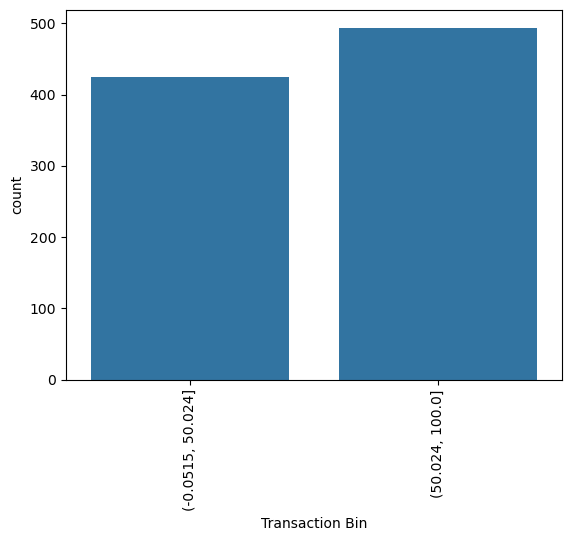

In [597]:
cut_data = pd.cut(df_fraud_job['Transaction percentage'], bins=2)
cut_df = pd.DataFrame({'Transaction Bin': cut_data})
plot = sns.countplot(x='Transaction Bin', data=cut_df)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [598]:
df_fraud_job.loc[(df_fraud_job.is_fraud == 1) & (df_fraud_job['Transaction percentage'] >= 50)].job

2                  Accountant, chartered
39                Air traffic controller
64        Armed forces technical officer
94                  Broadcast journalist
111                      Careers adviser
198           Contracting civil engineer
218                               Dancer
318                       Engineer, site
374              Forest/woodland manager
421                            Homeopath
450                     Industrial buyer
453                  Information officer
493                      Legal secretary
619                    Personnel officer
758    Sales promotion account executive
787                          Ship broker
795                            Solicitor
898                   Veterinary surgeon
906                    Warehouse manager
Name: job, dtype: object

##### **Observation ('job' Feature):**
- High transaction frequencies are noted in specific job roles.
- Jobs like Armed Forces Technical Officer, Engineer (Site), Information Officer, Legal Secretary, and others listed have *completely fraudulent transactions*.

In [600]:
df.category.value_counts(normalize=True)

category
gas_transport     0.101536
grocery_pos       0.095350
home              0.094947
shopping_pos      0.089978
kids_pets         0.087173
shopping_net      0.075225
entertainment     0.072504
food_dining       0.070535
personal_care     0.069993
health_fitness    0.066230
misc_pos          0.061430
misc_net          0.048807
grocery_net       0.035053
travel            0.031239
Name: proportion, dtype: float64

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\3186962843.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


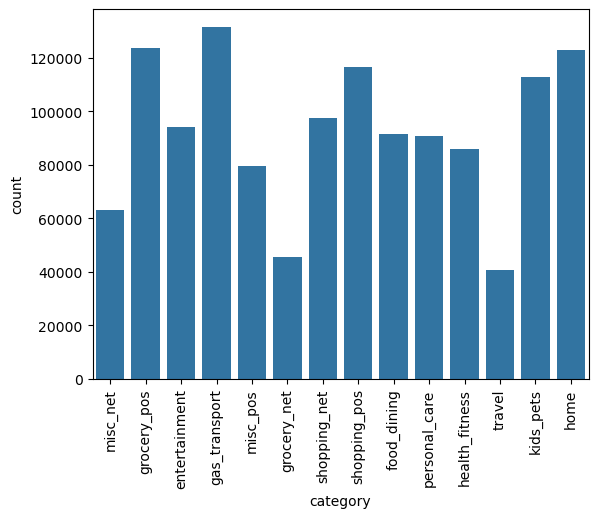

In [601]:
df['category'] = df['category'].astype(str)
plot = sns.countplot(x='category', data=df)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [602]:
df_category = df[['category','trans_num']].groupby(['category']).count().reset_index()
df_category.columns = ['category', 'category_count']

#creating the zip-fraud distribution
df_fraud_category = df[['category', 'trans_num', 'is_fraud']].groupby(['category','is_fraud']).count().reset_index()
df_fraud_category.columns = ['category', 'is_fraud', 'Transaction count']

df_fraud_category = df_fraud_category.merge(df_category[['category', 'category_count']], how='inner', on='category')

df_fraud_category['Transaction percentage'] = (df_fraud_category['Transaction count']/df_fraud_category['category_count'])*100

#viewing the top categories with high fraudulent transaction volumes
df_fraud_category[df_fraud_category['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False)

,category,is_fraud,Transaction count,category_count,Transaction percentage
23,shopping_net,1,1713,97543,1.756149
17,misc_net,1,915,63287,1.445795
9,grocery_pos,1,1743,123638,1.409761
25,shopping_pos,1,843,116672,0.722538
5,gas_transport,1,618,131659,0.469394
19,misc_pos,1,250,79655,0.313853
7,grocery_net,1,134,45452,0.294817
27,travel,1,116,40507,0.286370
1,entertainment,1,233,94014,0.247835
21,personal_care,1,220,90758,0.242403


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2866042641.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


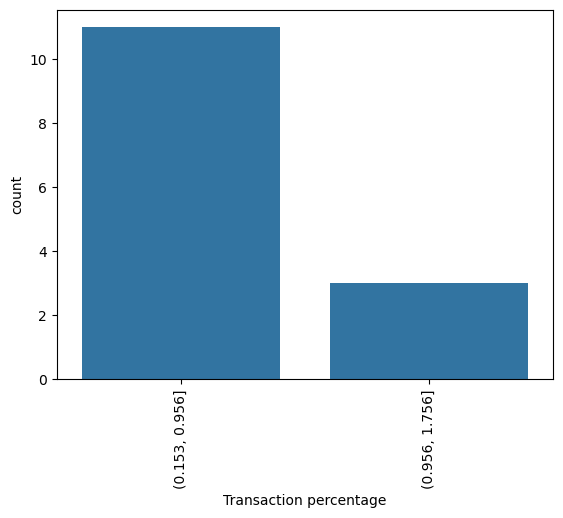

In [603]:
fraud_data = df_fraud_category[df_fraud_category.is_fraud == 1]['Transaction percentage']
if fraud_data.empty:
    print("Error: No fraudulent transactions found!")
else:
    fraud_bins = pd.cut(fraud_data, bins=2)
   
    fraud_bins = fraud_bins.astype(str)
    plot = sns.countplot(x=fraud_bins)
    plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
    plt.show()

In [604]:
df_fraud_category.loc[(df_fraud_category.is_fraud == 1) & (df_fraud_category['Transaction percentage'] >= 1)].category

9      grocery_pos
17        misc_net
23    shopping_net
Name: category, dtype: object

In [605]:
df_fraud_category.head()

,category,is_fraud,Transaction count,category_count,Transaction percentage
0,entertainment,0,93781,94014,99.752165
1,entertainment,1,233,94014,0.247835
2,food_dining,0,91310,91461,99.834902
3,food_dining,1,151,91461,0.165098
4,gas_transport,0,131041,131659,99.530606


#### **Observation ('category' Feature):**
- Three categories—grocery_pos, misc_net, and shopping_net—have over 1% fraudulent transactions, with shopping_net having the highest number of fraud cases.

#### **Inference:**
- The shopping_net category is particularly vulnerable to fraud, possibly due to compromised transaction systems or mechanisms used by fraudsters.
- These categories (grocery_pos, misc_net, shopping_net) should be thoroughly investigated and monitored to reduce fraudulent activities and improve transaction security.

In [607]:
df.merchant.nunique()

693

In [608]:
high_trans_merchants = df.merchant.value_counts().head(20).index.tolist()
high_trans_merchants

['fraud_Kilback LLC',
 'fraud_Cormier LLC',
 'fraud_Schumm PLC',
 'fraud_Kuhn LLC',
 'fraud_Boyer PLC',
 'fraud_Dickinson Ltd',
 'fraud_Cummerata-Jones',
 'fraud_Kutch LLC',
 'fraud_Olson, Becker and Koch',
 'fraud_Stroman, Hudson and Erdman',
 'fraud_Rodriguez Group',
 'fraud_Erdman-Kertzmann',
 'fraud_Jenkins, Hauck and Friesen',
 'fraud_Kling Inc',
 'fraud_Connelly, Reichert and Fritsch',
 'fraud_Friesen-Stamm',
 'fraud_Prohaska-Murray',
 'fraud_Huels-Hahn',
 'fraud_Berge LLC',
 'fraud_Bartoletti-Wunsch']

C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\204432241.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


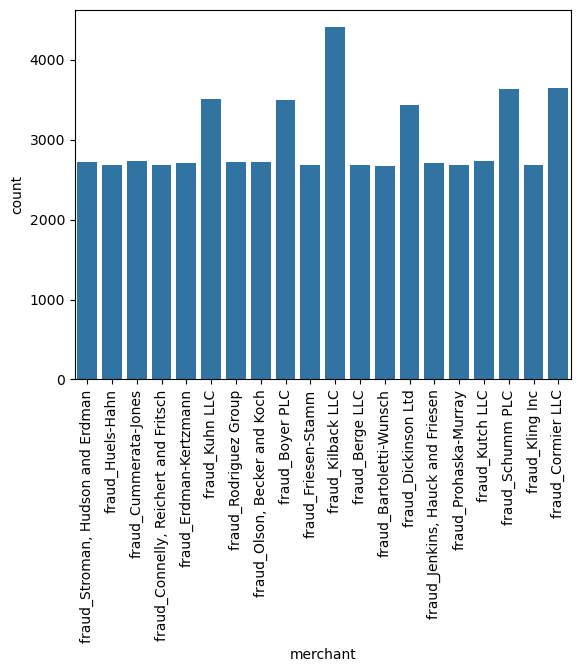

In [609]:
filtered_df = df[df.merchant.isin(high_trans_merchants)]
plot = sns.countplot(x=filtered_df.merchant)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.show()

In [610]:
df_merchant = df[['merchant','trans_num']].groupby(['merchant']).count().reset_index()
df_merchant.columns = ['merchant', 'merchant_count']
df_fraud_merchant = df[['merchant', 'trans_num', 'is_fraud']].groupby(['merchant','is_fraud']).count().reset_index()
df_fraud_merchant.columns = ['merchant', 'is_fraud', 'Transaction count']

df_fraud_merchant = df_fraud_merchant.merge(df_merchant[['merchant', 'merchant_count']], how='inner', on='merchant')

df_fraud_merchant['Transaction percentage'] = (df_fraud_merchant['Transaction count']/df_fraud_merchant['merchant_count'])*100
df_fraud_merchant[df_fraud_merchant['is_fraud'] == 1].sort_values(by = ['Transaction percentage'], ascending=False).head(20)

,merchant,is_fraud,Transaction count,merchant_count,Transaction percentage
672,fraud_Kozey-Boehm,1,48,1866,2.572347
489,"fraud_Herman, Treutel and Dickens",1,33,1300,2.538462
606,fraud_Kerluke-Abshire,1,41,1838,2.230686
159,fraud_Brown PLC,1,26,1176,2.210884
400,fraud_Goyette Inc,1,42,1943,2.161606
1220,fraud_Terry-Huel,1,43,1996,2.154309
562,fraud_Jast Ltd,1,42,1953,2.150538
1100,"fraud_Schmeler, Bashirian and Price",1,41,1968,2.083333
145,fraud_Boyer-Reichert,1,38,1908,1.991614
742,"fraud_Langworth, Boehm and Gulgowski",1,39,1969,1.980701


C:\Users\Yashvi Sharma\AppData\Local\Temp\ipykernel_1212\2938568713.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)


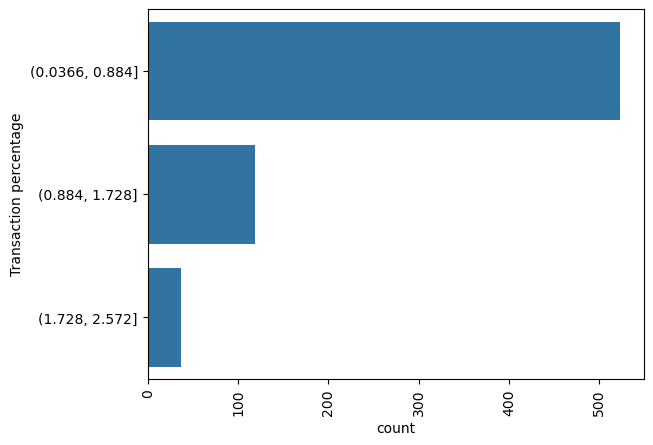

In [611]:
plot = sns.countplot(pd.cut(df_fraud_merchant[df_fraud_merchant.is_fraud == 1]['Transaction percentage'], bins = 3))
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)
plt.show()

In [612]:
len(df_fraud_merchant.loc[(df_fraud_merchant.is_fraud == 1) & (df_fraud_merchant['Transaction percentage'] >= 1)].merchant)

145

In [613]:
df_fraud_merchant.loc[(df_fraud_merchant.is_fraud == 1) & (df_fraud_merchant['Transaction percentage'] >= 2)].merchant

159                         fraud_Brown PLC
400                       fraud_Goyette Inc
489       fraud_Herman, Treutel and Dickens
562                          fraud_Jast Ltd
606                   fraud_Kerluke-Abshire
672                       fraud_Kozey-Boehm
1100    fraud_Schmeler, Bashirian and Price
1220                       fraud_Terry-Huel
Name: merchant, dtype: object

##### **Observation ('merchant' Feature):**
- About 140 merchants have over 1% of their transactions flagged as fraudulent.
- Top merchants with the highest fraudulent transactions include fraud_Brown PLC, fraud_Goyette Inc, fraud_Herman, Treutel and Dickens, fraud_Jast Ltd, fraud_Kerluke-Abshire, fraud_Kozey-Boehm, fraud_Schmeler, Bashirian and Price, and fraud_Terry-Huel.

##### **Inference:**
- These merchants should be investigated for potential fraudulent practices.
- They should also be alerted and educated on how to identify and prevent fraudulent activities to improve transaction security.

# **Step - 4: Feature Encoding**

In [616]:
category_onehot = pd.get_dummies(df.category, prefix='category', drop_first=True).astype(int)
gender_onehot = pd.get_dummies(df.gender, prefix='gender', drop_first=True).astype(int)
day_of_week_onehot = pd.get_dummies(df.trans_day_of_week, prefix='day', drop_first=True).astype(int)
age_onehot = pd.get_dummies(df.age, prefix='age', drop_first=True).astype(int)

In [617]:
df1 = pd.concat([df, category_onehot,gender_onehot,day_of_week_onehot,age_onehot], axis=1)
df1.head()

,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,...,age_87.0,age_88.0,age_89.0,age_90.0,age_91.0,age_92.0,age_93.0,age_94.0,age_95.0,age_96.0
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,...,0,0,0,0,0,0,0,0,0,0
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,...,0,0,0,0,0,0,0,0,0,0
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,...,0,0,0,0,0,0,0,0,0,0
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,...,0,0,0,0,0,0,0,0,0,0
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,...,0,0,0,0,0,0,0,0,0,0


In [618]:
df1.drop([ 'cc_num', 'trans_num'], axis=1, inplace=True)
print(df1.shape)
df1.columns

(1296675, 122)


Index(['merchant', 'category', 'amt', 'gender', 'street', 'city', 'state',
       'zip', 'lat', 'long',
       ...
       'age_87.0', 'age_88.0', 'age_89.0', 'age_90.0', 'age_91.0', 'age_92.0',
       'age_93.0', 'age_94.0', 'age_95.0', 'age_96.0'],
      dtype='object', length=122)

In [619]:
df1.drop(['merchant','street','city','state','job',
          'category','gender','trans_day_of_week',
          'age'],axis=1, inplace=True)
df1.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'trans_hour',
       ...
       'age_87.0', 'age_88.0', 'age_89.0', 'age_90.0', 'age_91.0', 'age_92.0',
       'age_93.0', 'age_94.0', 'age_95.0', 'age_96.0'],
      dtype='object', length=113)

- Now, some features like 'cc_num', 'first', 'last', 'trans_num' are not significant in context of our analysis and hence can be removed.
- In the df1 DataFrame, the **'merchant'** feature can be dropped due to its high number of unique values, making it difficult to encode effectively. The same applies to the variables **'street'**, **'city'**, **'state'**, and **'job'**.
- Additionally, the variables **'age'**, **'category'**, **'gender'**, and **'trans_day_of_week'** can also be dropped as they have already been encoded and their information is preserved in the dataset.

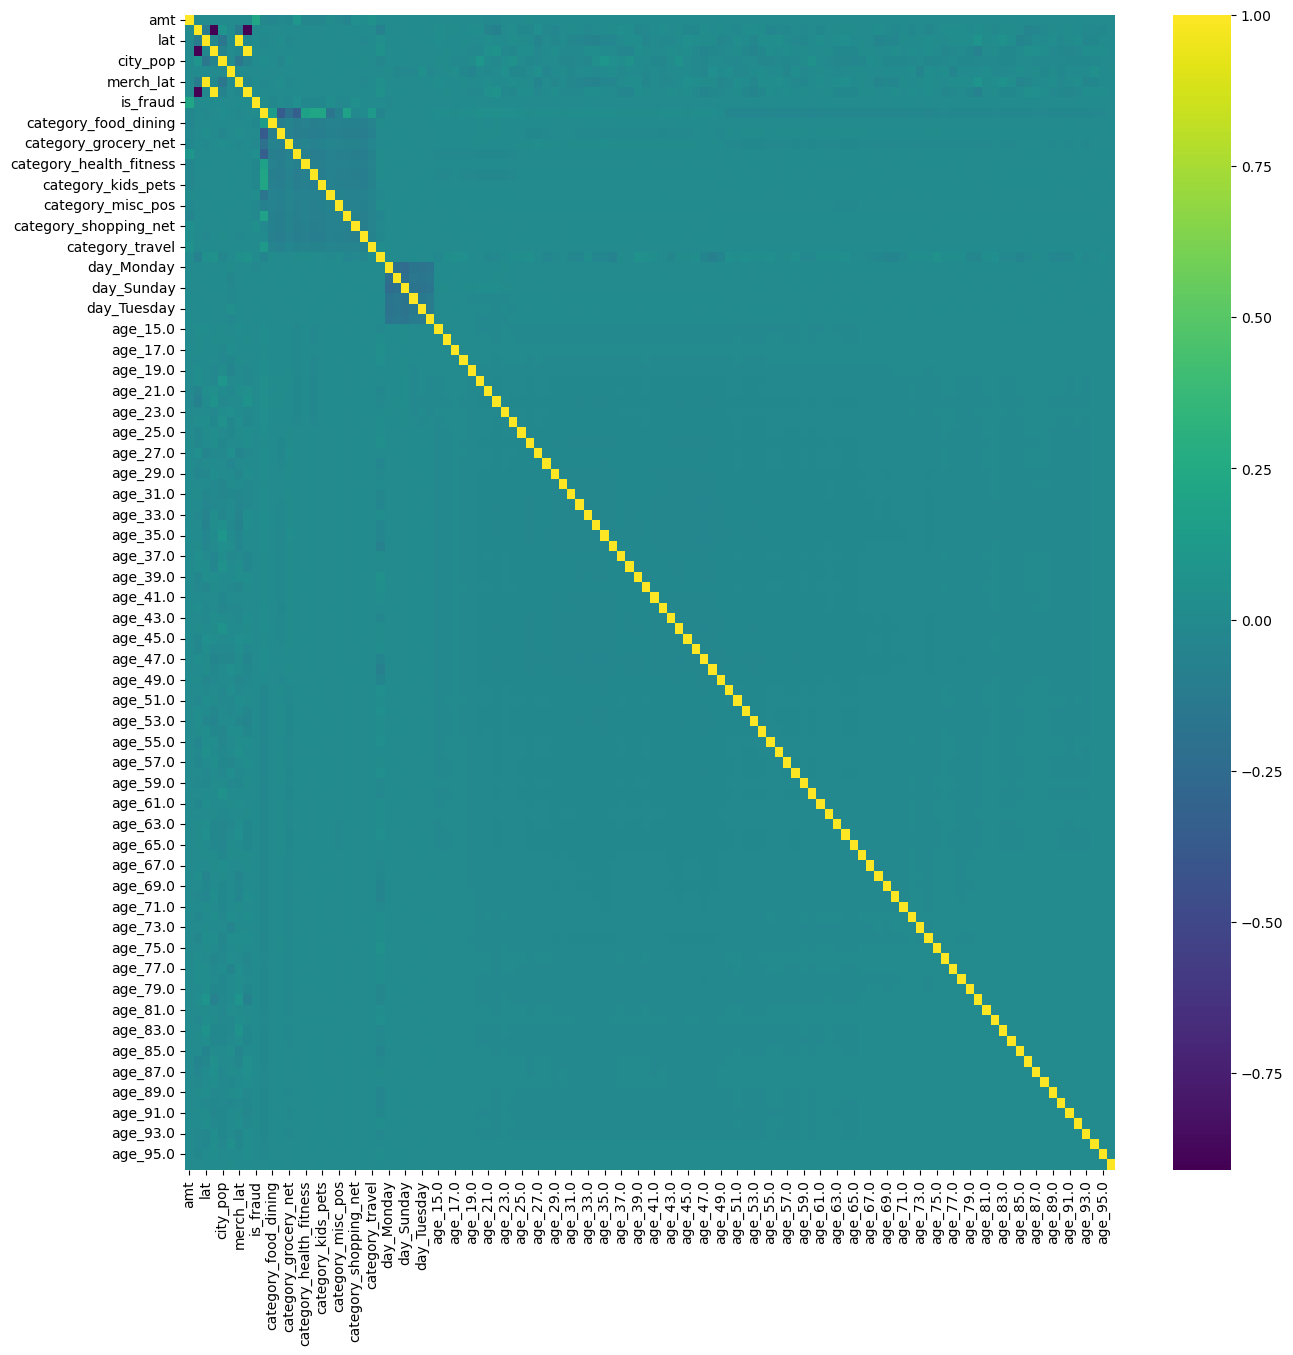

In [621]:
df_numeric = df1.select_dtypes(include=['number']) 
df_random_under_corr = df_numeric.corr()
plt.figure(figsize=(15,15))
sns.heatmap(df_random_under_corr, cmap="viridis")
plt.show()

In [622]:
def correlation(dataset, threshold):
    col_corr = set() 
    corr_matrix = dataset.corr() 
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j] > threshold:
                colname = corr_matrix.columns[i] #selecting columns above threshold
                col_corr.add(colname) #adding columns to set
    return col_corr

In [623]:
df_numeric = df1.select_dtypes(include=['number']) 
corr_features = correlation(df_numeric,0.85)
corr_features

{'merch_lat', 'merch_long'}

- As it can be seen, there are no features that have a correlation of above 85% apart from merchant lat and long. Hence, it is safe to proceed with out model building.

# **Step - 5: Model Training and Selection**

In [626]:
df_num = df1.select_dtypes(include='number')
df_num.drop(['zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat','merch_long'],
            axis=1, inplace=True)
df_num.columns.tolist()

['amt',
 'is_fraud',
 'trans_hour',
 'category_food_dining',
 'category_gas_transport',
 'category_grocery_net',
 'category_grocery_pos',
 'category_health_fitness',
 'category_home',
 'category_kids_pets',
 'category_misc_net',
 'category_misc_pos',
 'category_personal_care',
 'category_shopping_net',
 'category_shopping_pos',
 'category_travel',
 'gender_M',
 'day_Monday',
 'day_Saturday',
 'day_Sunday',
 'day_Thursday',
 'day_Tuesday',
 'day_Wednesday',
 'age_15.0',
 'age_16.0',
 'age_17.0',
 'age_18.0',
 'age_19.0',
 'age_20.0',
 'age_21.0',
 'age_22.0',
 'age_23.0',
 'age_24.0',
 'age_25.0',
 'age_26.0',
 'age_27.0',
 'age_28.0',
 'age_29.0',
 'age_30.0',
 'age_31.0',
 'age_32.0',
 'age_33.0',
 'age_34.0',
 'age_35.0',
 'age_36.0',
 'age_37.0',
 'age_38.0',
 'age_39.0',
 'age_40.0',
 'age_41.0',
 'age_42.0',
 'age_43.0',
 'age_44.0',
 'age_45.0',
 'age_46.0',
 'age_47.0',
 'age_48.0',
 'age_49.0',
 'age_50.0',
 'age_51.0',
 'age_52.0',
 'age_53.0',
 'age_54.0',
 'age_55.0',
 'age_

In [627]:
X = df_num.drop(['is_fraud'],axis=1)
y = df_num.is_fraud

In [628]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [629]:
skf = StratifiedKFold(n_splits=2)
skf.get_n_splits(X,y)

for train_index, test_index in skf.split(X,y):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]

y_train.value_counts()

is_fraud
0    644585
1      3753
Name: count, dtype: int64

In [630]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

## **Logistic Regression**

In [632]:
lr = LogisticRegression(random_state=42)

In [633]:
model = lr.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
print('y_train_pred: ',y_train_pred)
y_test_pred = model.predict(X_test)
print('y_test_pred: ', y_test_pred)

y_train_pred:  [0 0 0 ... 0 0 0]
y_test_pred:  [0 0 0 ... 0 0 0]


In [634]:
model_name = 'Logistic Regression - without balancing'
train_score = model.score(X_train,y_train)
test_score = model.score(X_test,y_test)

acc_score = accuracy_score(y_test,y_test_pred)
f_score = f1_score(y_test, y_test_pred, average='weighted')
precision = precision_score(y_test, y_test_pred)
recall = metrics.recall_score(y_test,y_test_pred)

model_eval_data = [[model_name, train_score, test_score, acc_score, f_score, precision, recall]]
evaluate_df = pd.DataFrame(model_eval_data, columns=['Model Name', 'Training Score', 'Testing Score', 'Accuracy',
                                          'F1 Score', 'Precision', 'Recall'])
evaluate_df

,Model Name,Training Score,Testing Score,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression - without balancing,0.993915,0.993867,0.993867,0.991273,0.136808,0.011191


### **Impacts of Imbalance:**
- From the above dataframe it can be seen that although we have not balanced the classes in our target variable, the accuracy and several other metrics seem to look great.
- This is because, since there is no balance in the dataset at this point, the model predicts almost all data points as 'not fraud'.
- This does not clearly satify our motive hence, we need to balance the classes in the target variable in order build a fair model.

In [636]:
test_input = X_test.copy()
test_output = y_test.copy()

test_output.value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

In [637]:
fraud_trans = df_num[df_num['is_fraud'] == 1]
non_fraud_trans = df_num[df_num['is_fraud'] == 0]

print('fraud data shape: ', fraud_trans.shape)
print('non fraud data shape: ', non_fraud_trans.shape)
print('Fraud Data percentage: ', 100*(len(fraud_trans)/len(non_fraud_trans)))

fraud data shape:  (7506, 105)
non fraud data shape:  (1289169, 105)
Fraud Data percentage:  0.5822355331224999


### **1) Random Undersampling:**
- *for this, we will use the sample method to randomly choose the total number of data points from majority class as in the minority class.*

In [639]:
rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_train, y_train)

In [640]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.3, random_state=42, stratify=y_rus
)

In [641]:
lrr = LogisticRegression(random_state=42)
model = lrr.fit(X_train, y_train)

In [642]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [643]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82      1126
           1       0.84      0.77      0.80      1126

    accuracy                           0.81      2252
   macro avg       0.82      0.81      0.81      2252
weighted avg       0.82      0.81      0.81      2252



In [644]:
model_name = 'Logistic Regression - with balancing'
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
acc_score = accuracy_score(y_test, y_test_pred)
f_score = f1_score(y_test, y_test_pred, average='weighted')
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

In [645]:
evaluate_df = pd.DataFrame(
    [[model_name, train_score, test_score, acc_score, f_score, precision, recall]],
    columns=['Model Name', 'Training Score', 'Testing Score', 'Accuracy',
             'F1 Score', 'Precision', 'Recall']
)

In [646]:
evaluate_df

,Model Name,Training Score,Testing Score,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression - with balancing,0.830796,0.813055,0.813055,0.812722,0.841901,0.77087


### **2) SMOTE**

In [648]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [649]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42, stratify=y_smote)

In [650]:
lrs = LogisticRegression(random_state=42)
model = lrs.fit(X_train, y_train)

In [651]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [652]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       789
           1       0.85      0.78      0.81       788

    accuracy                           0.82      1577
   macro avg       0.82      0.82      0.82      1577
weighted avg       0.82      0.82      0.82      1577



In [653]:
# Evaluation Metrics
model_name = 'Logistic Regression - with SMOTE'
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
acc_score = accuracy_score(y_test, y_test_pred)
f_score = f1_score(y_test, y_test_pred, average='weighted')
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

In [654]:
model_eval_data = [[model_name, train_score, test_score, acc_score, f_score, precision, recall]]
evaluate_df = pd.DataFrame(model_eval_data, columns=['Model Name', 'Training Score', 'Testing Score', 'Accuracy', 
                                                      'F1 Score', 'Precision', 'Recall'])
evaluate_df

,Model Name,Training Score,Testing Score,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression - with SMOTE,0.838999,0.819277,0.819277,0.818984,0.846897,0.779188


## **Random Forest**

In [656]:
rf = RandomForestClassifier(random_state=42)
model_rf = rf.fit(X_train, y_train)

In [657]:
y_test_pred_rf = model_rf.predict(X_test)

In [658]:
model_eval_data = [[
    "Random Forest - Without Balancing",
    model_rf.score(X_train, y_train),
    model_rf.score(X_test, y_test),
    accuracy_score(y_test, y_test_pred_rf),
    f1_score(y_test, y_test_pred_rf, average="weighted"),
    precision_score(y_test, y_test_pred_rf),
    recall_score(y_test, y_test_pred_rf),
]]

In [659]:
model_eval_data

[['Random Forest - Without Balancing',
  1.0,
  0.9651236525047558,
  0.9651236525047558,
  0.9651218012478642,
  0.9716859716859717,
  0.9581218274111675]]

In [660]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       789
           1       0.97      0.96      0.96       788

    accuracy                           0.97      1577
   macro avg       0.97      0.97      0.97      1577
weighted avg       0.97      0.97      0.97      1577



### **2) SMOTE**

In [668]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [669]:
rf_smote = RandomForestClassifier(random_state=42)
model_smote = rf_smote.fit(X_smote, y_smote)
y_test_pred_smote = model_smote.predict(X_test)

In [670]:
model_eval_data.append([
    "Random Forest - With SMOTE",
    model_smote.score(X_smote, y_smote),
    model_smote.score(X_test, y_test),
    accuracy_score(y_test, y_test_pred_smote),
    f1_score(y_test, y_test_pred_smote, average="weighted"),
    precision_score(y_test, y_test_pred_smote),
    recall_score(y_test, y_test_pred_smote),
])

In [671]:
evaluate_df = pd.DataFrame(
    model_eval_data, 
    columns=["Model Name", "Training Score", "Testing Score", "Accuracy", "F1 Score", "Precision", "Recall"]
)

In [672]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred_smote))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       789
           1       0.97      0.96      0.97       788

    accuracy                           0.97      1577
   macro avg       0.97      0.97      0.97      1577
weighted avg       0.97      0.97      0.97      1577



## **XG Boost**

In [688]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [689]:
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

C:\Users\Yashvi Sharma\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:34:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [690]:
y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

In [691]:
model_name = 'XGBoost - Without Balancing'
train_score = xgb_clf.score(X_train, y_train)
test_score = xgb_clf.score(X_test, y_test)
acc_score = accuracy_score(y_test, y_test_pred)
f_score = f1_score(y_test, y_test_pred, average='weighted')
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

In [692]:
model_eval_data = [[model_name, train_score, test_score, acc_score, f_score, precision, recall]]

### **SMOTE Sampling**

In [694]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [695]:
xgb_clf_smote = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf_smote.fit(X_train_smote, y_train_smote)

C:\Users\Yashvi Sharma\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:34:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [696]:
y_test_pred_smote = xgb_clf_smote.predict(X_test)

In [697]:
model_name = 'XGBoost - With SMOTE'
train_score = xgb_clf_smote.score(X_train_smote, y_train_smote)
test_score = xgb_clf_smote.score(X_test, y_test)
acc_score = accuracy_score(y_test, y_test_pred_smote)
f_score = f1_score(y_test, y_test_pred_smote, average='weighted')
precision = precision_score(y_test, y_test_pred_smote)
recall = recall_score(y_test, y_test_pred_smote)

In [698]:
model_eval_data.append([model_name, train_score, test_score, acc_score, f_score, precision, recall])

In [699]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred_smote))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       789
           1       0.98      0.96      0.97       788

    accuracy                           0.97      1577
   macro avg       0.97      0.97      0.97      1577
weighted avg       0.97      0.97      0.97      1577



### **RandomUnder Sampling**

In [701]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [702]:
xgb_clf_rus = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf_rus.fit(X_train_rus, y_train_rus)

C:\Users\Yashvi Sharma\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:34:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [703]:
y_test_pred_rus = xgb_clf_rus.predict(X_test)

model_name = 'XGBoost - With Random Undersampling'
train_score = xgb_clf_rus.score(X_train_rus, y_train_rus)
test_score = xgb_clf_rus.score(X_test, y_test)
acc_score = accuracy_score(y_test, y_test_pred_rus)
f_score = f1_score(y_test, y_test_pred_rus, average='weighted')
precision = precision_score(y_test, y_test_pred_rus)
recall = recall_score(y_test, y_test_pred_rus)

In [704]:
model_eval_data.append([model_name, train_score, test_score, acc_score, f_score, precision, recall])

In [705]:
evaluate_df = pd.DataFrame(model_eval_data, columns=['Model Name', 'Training Score', 'Testing Score', 'Accuracy',
                                                      'F1 Score', 'Precision', 'Recall'])

## **Decision Tree**

In [708]:
dt_clf = DecisionTreeClassifier(random_state=42)

In [709]:
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [710]:
dt_preds = dt_clf.predict(X_test)

In [711]:
print("\nDecision Tree Classifier Performance:")
print(classification_report(y_test, dt_preds))
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")


Decision Tree Classifier Performance:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       789
           1       0.96      0.95      0.95       788

    accuracy                           0.95      1577
   macro avg       0.95      0.95      0.95      1577
weighted avg       0.95      0.95      0.95      1577

Accuracy: 0.9537


### **SMOTE**

In [718]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [719]:
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [720]:
y_pred_smote = dt_smote.predict(X_test)

In [721]:
y_pred_smote_ = dt_smote.predict(X_train_smote)

In [722]:
smote_results = {
    "Method": "SMOTE (OverSampling)",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1-Score": f1_score(y_test, y_pred_smote)
}

In [723]:
evaluate_df = pd.DataFrame([rus_results, smote_results])
print(evaluate_df)

                 Method  Accuracy  Precision    Recall  F1-Score
0   RUS (UnderSampling)   0.95371   0.956577  0.950508  0.953533
1  SMOTE (OverSampling)   0.95371   0.956577  0.950508  0.953533


# **Step- 6 Deploy Model**

In [730]:
import pickle
from datetime import datetime  
X_train = pd.DataFrame(X_train, columns=feature_names)

NameError: name 'feature_names' is not defined

In [728]:
model_info = {
    "model": model_smote,
    "features": X_train.columns.tolist()  
}

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
with open("model.pkl", "wb") as file:
    pickle.dump(model_info, file)

In [ ]:
validation_df

In [ ]:
model = joblib.load("C:/Users/Yashvi Sharma/Desktop/Financial_Fraud/model/model.pkl")